In [1]:
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
import pandas            as pd
import SO_library        as sol
import json
import os

# Assuming the `bin` directory is in the user's home directory
# For sqs
home_directory = os.path.expanduser("~")
bin_directory = os.path.join(home_directory, "bin")
os.environ["PATH"] += os.pathsep + bin_directory

from pymatgen.core.surface   import generate_all_slabs
from pymatgen.core.structure import Structure
from pymatgen.io.ase         import AseAtomsAdaptor
from ase.io.vasp             import write_vasp

sns.set_theme()

/home/claudio/cibran/Work/UPC/SlabOptimization/venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_in

We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name of folder and path to reference POSCAR
general_folder = 'input/BiSeBr'
path_to_POSCAR = 'POSCAR-uc-BiSeBr'

# Maximum number for the Miller index in each direction
max_index = 2

# Whether to repair terminations with broken bonds or just omit them
repair = True

# Minimum thicknesses for slab and vacuum
min_slab_size   = 20.0
min_vacuum_size = 20.0

relax_bulk = True

# Define paths to pretrained model and structure to be relaxed
# Materials Project pretrained model as default
#model_load_path = '../../UCL/m3gnet/finetuned_model'
model_load_path = None
model_load_path = 'large' if model_load_path is None else model_load_path
model_load_path

'large'

In [3]:
# Move POSCAR to defect folder
# The folder is named as defects_x_y_z_vi (eg, defects_0_1_0.5_v0)
# Each new run generates a new folder, with different defects most likely (as POSCAR will vary as well)
i = 0
while True:
    if not os.path.exists(general_folder):
        # Generate new folder
        os.system(f'mkdir {general_folder}')
    
    slab_folder = f'{general_folder}/slab_v{i}'
    if not os.path.exists(slab_folder):
        # Generate new folder
        os.system(f'mkdir {slab_folder}')

        # Copy POSCAR there (named as unticell, and POSCAR for creating supercell)
        os.system(f'cp {path_to_POSCAR} {slab_folder}/POSCAR')
        break
    i +=1
slab_folder

'input/BiSeBr/slab_v0'

# ML-IAP relaxation

In [4]:
# Unit-cell relaxation

# Define paths to bulk and POSCAR
path_to_bulk = f'{slab_folder}/bulk'

# Generate directory for current slab
os.system(f'mkdir {path_to_bulk}')

# Copy POSCAR to new directory
os.system(f'cp {slab_folder}/POSCAR {path_to_bulk}/POSCAR')

if relax_bulk:
    # Relax the structure, hiding the output (verbose=False)
    _ = sol.structural_relaxation(f'{path_to_bulk}/POSCAR',
                                  model_load_path,
                                  output_folder=path_to_bulk)

    # Get the single-shot energy
    bulk_energy, _, _ = sol.single_shot_energy_calculation(f'{path_to_bulk}/CONTCAR',
                                                           model_load_path)
else:
    os.system(f'cp {slab_folder}/POSCAR {path_to_bulk}/CONTCAR')

# Read relaxed structure
structure = Structure.from_file(f'{path_to_bulk}/CONTCAR')

# Save slab information
slab_data = {
    'number_of_sites': structure.num_sites,
}
with open(f'{path_to_bulk}/slab_data.json', 'w') as json_file:
    json.dump(slab_data, json_file)

Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/claudio/cibran/Work/UPC/SlabOptimization/venv/lib/python3.12/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

      Step     Time          Energy          fmax
BFGS:    0 14:12:13      -42.195026        7.926842
BFGS:    1 14:12:13      -40.199476       20.013286
BFGS:    2 14:12:13      -42.441425        2.184732
BFGS:    3 14:12:14      -42.481399        1.055458
BFGS:    4 14:12:14      -42.505250        0.786030
BFGS:    5 14:12:14      -42.640496        0.475619
BFGS:    6 14:12:14      -42.650919        0.232804
BFGS:    7 14:12:14      -42.660252        0.328124
BFGS:    8 14:12:14      -42.693536        0.607397
BFGS:    9 14:12:14      -42.720801        0.604787
BFGS:   10 14:12:14      -42.737568        0.465993
BFGS:   11 14:12:14      -42.750306        0.278925
BFGS:   12 14:12:14      -42.754412        0.184730
BFGS:   13 14:12:14      -42.759451        0.247362
BFGS:   14 14:12:14      -42.778420        0.724880
BFGS:   15 14:12:14      -42.797861        0.863639
BFGS:   16 14:12:14      -42.813738        0.566814
BFGS:   17 14:12:14      -42.818746        0.167877
BFGS:   18 14:

/home/claudio/cibran/Work/UPC/SlabOptimization/venv/lib/python3.12/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

# Slab generation

In [5]:
# Generate all slabs
slabs = generate_all_slabs(structure,
                           max_index=max_index,
                           min_slab_size=min_slab_size,
                           min_vacuum_size=min_vacuum_size,
                           repair=repair)

# Get energy per atom
bulk_energy_per_atom = bulk_energy / structure.num_sites

In [6]:
for n, slab in enumerate(slabs):
    print(n, "Polar:", slab.is_polar(), "Symmetric: ", slab.is_symmetric())

0 Polar: False Symmetric:  True
1 Polar: False Symmetric:  False
2 Polar: False Symmetric:  False
3 Polar: False Symmetric:  False
4 Polar: False Symmetric:  False
5 Polar: False Symmetric:  False
6 Polar: False Symmetric:  True
7 Polar: False Symmetric:  True
8 Polar: False Symmetric:  True
9 Polar: False Symmetric:  False
10 Polar: False Symmetric:  False
11 Polar: False Symmetric:  True
12 Polar: False Symmetric:  True
13 Polar: False Symmetric:  True
14 Polar: False Symmetric:  False
15 Polar: False Symmetric:  False
16 Polar: False Symmetric:  False
17 Polar: False Symmetric:  True
18 Polar: False Symmetric:  False
19 Polar: False Symmetric:  False
20 Polar: False Symmetric:  True
21 Polar: False Symmetric:  True
22 Polar: False Symmetric:  True
23 Polar: False Symmetric:  False
24 Polar: False Symmetric:  False
25 Polar: False Symmetric:  True
26 Polar: False Symmetric:  True
27 Polar: False Symmetric:  False
28 Polar: False Symmetric:  False
29 Polar: False Symmetric:  False
30 

Surface formation energy of shape $S$ for slab of energy $E_S$ with $N$ formula units and $E_{bulk}$ bulk energy is:

\begin{equation}
    E_S = \frac{E_S - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [7]:
# Initialize the data dictionary for storing all slab energy calculations
# Iterate over slabs
slab_energies = {}
for i, slab in enumerate(slabs):
    print()
    print(f'Slab {i+1}')
    print()
    print('Miller index:', slab.miller_index)
    print('Shift:', slab.shift)
    print('Surface area:', slab.surface_area)
    print('Number of sites:', len(slab.sites))

    # Miller index tuple to string
    miller_index_str = '_'.join(str(element) for element in slab.miller_index)
    miller_index_str = f'{miller_index_str}_i_{i}'

    # Define current folder
    current_folder = f'{slab_folder}/{miller_index_str}'

    # Generate new folder
    os.system(f'mkdir {current_folder}')

    # Save slab into current_folder
    write_vasp(f'{current_folder}/POSCAR', AseAtomsAdaptor.get_atoms(slab), direct=True, sort=True)

    # Save slab information
    slab_data = {
        'miller_index': slab.miller_index,
        'shift': slab.shift,
        'surface_area': slab.surface_area,
        'number_of_sites': len(slab.sites),
        'is_polar': str(slab.is_polar()),
        'is_symmetric': str(slab.is_symmetric())
    }
    with open(f'{current_folder}/slab_data.json', 'w') as json_file:
        json.dump(slab_data, json_file)
    
    # Relax the structure, hiding the output (verbose=False)
    _ = sol.structural_relaxation(f'{current_folder}/POSCAR',
                                  model_load_path,
                                  relax_cell=False,
                                  output_folder=current_folder)

    # Get and save the single-shot energy
    ssc_energy, _, _ = sol.single_shot_energy_calculation(f'{current_folder}/CONTCAR',
                                                          model_load_path)
    np.savetxt(f'{current_folder}/single_shot_energy', [ssc_energy])

    # Get energy per atom
    ssc_energy_per_atom = ssc_energy / len(slab.sites)

    # Compute slab energy in eV/atom/ang^2
    slab_energy = (ssc_energy_per_atom - bulk_energy_per_atom) / (2 * slab.surface_area)

    print(f'\t{slab_energy} eV/atom/Å^2')

    # Generate a dictionary object with the new data and update in the main data object
    slab_energies.update({
        (miller_index_str): slab_energy
    })

# Convert to Pandas DataFrame
slab_energies = pd.DataFrame(slab_energies, index=['energy'])


Slab 1

Miller index: (1, 1, 1)
Shift: 3.552713678800501e-15
Surface area: 121.6353703461385
Number of sites: 72
Using Materials Project MACE for MACECalculator with /home/claudio/.cache/mace/MACE_MPtrj_20229model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
      Step     Time          Energy          fmax
BFGS:    0 14:12:28     -252.648766        1.298153


/home/claudio/cibran/Work/UPC/SlabOptimization/venv/lib/python3.12/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

BFGS:    1 14:12:28     -252.867619        1.188380
BFGS:    2 14:12:28     -253.717645        1.639597
BFGS:    3 14:12:28     -253.916072        0.851680
BFGS:    4 14:12:28     -254.023976        0.765041
BFGS:    5 14:12:28     -254.281058        0.629763
BFGS:    6 14:12:28     -254.354074        0.319608
BFGS:    7 14:12:28     -254.378850        0.332750
BFGS:    8 14:12:28     -254.557763        0.503155
BFGS:    9 14:12:29     -254.618797        0.420255
BFGS:   10 14:12:29     -254.693664        0.316321
BFGS:   11 14:12:29     -254.739463        0.382883
BFGS:   12 14:12:29     -254.824509        0.335038
BFGS:   13 14:12:29     -254.863563        0.245174
BFGS:   14 14:12:29     -254.884147        0.224463
BFGS:   15 14:12:29     -254.899939        0.180080
BFGS:   16 14:12:29     -254.917913        0.229684
BFGS:   17 14:12:29     -254.937869        0.212428
BFGS:   18 14:12:29     -254.953698        0.146057
BFGS:   19 14:12:29     -254.962940        0.168097
BFGS:   20 1

/home/claudio/cibran/Work/UPC/SlabOptimization/venv/lib/python3.12/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

      Step     Time          Energy          fmax
BFGS:    0 14:12:31     -250.798788        1.638107
BFGS:    1 14:12:31     -251.033517        1.460494
BFGS:    2 14:12:32     -252.078129        1.053336
BFGS:    3 14:12:32     -252.175569        0.924873
BFGS:    4 14:12:32     -252.567047        0.653148
BFGS:    5 14:12:32     -252.627861        0.465445
BFGS:    6 14:12:32     -252.679892        0.479189
BFGS:    7 14:12:32     -252.897391        0.524140
BFGS:    8 14:12:32     -252.961647        0.606334
BFGS:    9 14:12:32     -253.036039        0.621190
BFGS:   10 14:12:32     -253.105835        0.645625
BFGS:   11 14:12:32     -253.211751        0.472547
BFGS:   12 14:12:32     -253.265803        0.343073
BFGS:   13 14:12:32     -253.297954        0.289145
BFGS:   14 14:12:32     -253.322676        0.305215
BFGS:   15 14:12:33     -253.359149        0.404639
BFGS:   16 14:12:33     -253.407735        0.403956
BFGS:   17 14:12:33     -253.453220        0.332188
BFGS:   18 14:

...

/home/claudio/cibran/Work/UPC/SlabOptimization/venv/lib/python3.12/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

      Step     Time          Energy          fmax
BFGS:    0 14:29:16     -168.246110        1.298645
BFGS:    1 14:29:16     -168.369717        1.134010
BFGS:    2 14:29:16     -168.830445        0.901376
BFGS:    3 14:29:16     -168.872534        0.896927
BFGS:    4 14:29:16     -169.006910        0.838452
BFGS:    5 14:29:16     -169.219615        0.642245
BFGS:    6 14:29:16     -169.293974        0.631144
BFGS:    7 14:29:16     -169.338768        0.419805
BFGS:    8 14:29:16     -169.368559        0.374598
BFGS:    9 14:29:16     -169.384160        0.294803
BFGS:   10 14:29:17     -169.419589        0.228187
BFGS:   11 14:29:17     -169.430391        0.292825
BFGS:   12 14:29:17     -169.440184        0.319382
BFGS:   13 14:29:17     -169.453567        0.289225
BFGS:   14 14:29:17     -169.471366        0.197379
BFGS:   15 14:29:17     -169.486295        0.238412
BFGS:   16 14:29:17     -169.496673        0.304518
BFGS:   17 14:29:17     -169.506107        0.311489
BFGS:   18 14:

/home/claudio/cibran/Work/UPC/SlabOptimization/venv/lib/python3.12/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

      Step     Time          Energy          fmax
BFGS:    0 14:29:19     -166.998356        1.309860
BFGS:    1 14:29:19     -167.166035        1.137091
BFGS:    2 14:29:19     -167.901074        0.971432
BFGS:    3 14:29:19     -167.981757        0.891108
BFGS:    4 14:29:19     -168.563888        0.722666
BFGS:    5 14:29:19     -168.760721        0.737024
BFGS:    6 14:29:19     -168.814781        0.479503
BFGS:    7 14:29:19     -168.874923        0.377861
BFGS:    8 14:29:19     -168.914508        0.267219
BFGS:    9 14:29:19     -168.957314        0.255172
BFGS:   10 14:29:20     -168.978322        0.296949
BFGS:   11 14:29:20     -168.994694        0.326934
BFGS:   12 14:29:20     -169.016849        0.300911
BFGS:   13 14:29:20     -169.043535        0.207376
BFGS:   14 14:29:20     -169.063568        0.199243
BFGS:   15 14:29:20     -169.074867        0.234352
BFGS:   16 14:29:20     -169.085211        0.243053
BFGS:   17 14:29:20     -169.103082        0.211197
BFGS:   18 14:

/home/claudio/cibran/Work/UPC/SlabOptimization/venv/lib/python3.12/site-packages/mace/calculators/mace.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=mod

# Extract local minimas and generate input files

In [8]:
# Sorted in ascendent order
min_arg       = np.argsort(slab_energies.values)[0]
local_minimas = slab_energies.columns[min_arg]
energies      = slab_energies.values[0][min_arg]

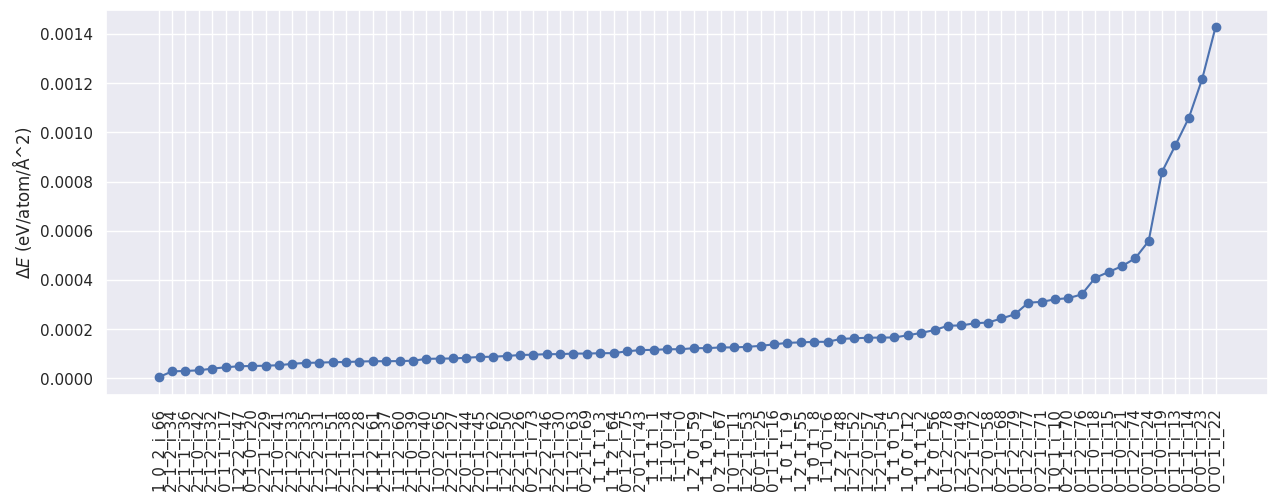

In [9]:
# Energy differences in eV/supercell
plt.figure(figsize=(15, 5))
plt.plot(energies, 'o-')
plt.xticks(range(len(local_minimas)), local_minimas, rotation='vertical')
plt.ylabel(r'$\Delta E$ (eV/atom/Å^2)')
plt.savefig(f'{slab_folder}/ranking.eps', dpi=50, bbox_inches='tight')
plt.show()